# `pipeline_hopfield_completo_36k` — Pipeline Completo com o Genoma Total (36.591 genes)

Experimento de controle científico na totalidade dos genes nativos do Fujita, conforme **ADR 007**.

**Contexto biológico e arquitetural.** O experimento parte de matrizes binárias de expressão
gênica (~40.000 células Fujita × ~45.000 células Mathys). Em contraste com as abordagens anteriores,
**nenhum recorte dimensional é realizado**, utilizando-se integralmente o genoma canônico do Fujita
(**36.591 genes**). Os genes do Fujita que não foram sequenciados no Mathys (~6.289 genes)
mantêm o **valor sentinela neutro 0.5**.

**Diferenças principais do novo teste (ADR 007):**
- Espaço gênico total de **36.591 genes** (sem filtro de frequência ou Qui-Quadrado).
- Otimização de RAM na Seção 13 com processamento em lotes (`batch_size=512`).
- A matriz imputada final é convertida e salva em formato **`.h5ad` esparso com compressão gzip**, reduzindo o tamanho em disco em mais de 90%.
- Parâmetros idênticos por controle científico: `rSWeeP=600D`, `nc=30` subclusters por classe K-Means (**210 padrões** na Hopfield) e `beta=50.0`.

**Rede utilizada:** Modern Hopfield Network (Ramsauer et al., 2020) com
capacidade de armazenamento exponencial e recuperação equivalente a um passo
de *attention* (`softmax(β · Ξ · ξ) · Ξᵀ`).

## 1. Imports e configuração


In [1]:
import sys, os

if hasattr(sys.stdout, 'reconfigure'):
    sys.stdout.reconfigure(encoding='utf-8')
if hasattr(sys.stderr, 'reconfigure'):
    sys.stderr.reconfigure(encoding='utf-8')

import gc
import importlib
import numpy as np
import pandas as pd
import polars as pl
import torch
import anndata as ad
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, f1_score, classification_report

SRC_DIR = os.path.join(os.path.dirname(os.path.abspath(__file__)), 'src')
if SRC_DIR not in sys.path:
    sys.path.insert(0, SRC_DIR)

import config
importlib.reload(config)
from config import (
    PATH_M, PATH_F, PATH_FEATURES_F, PATH_FEATURES_M,
    PATH_SWEEP_F, PATH_SWEEP_M, PATH_LABELS_F, PATH_LABELS_M,
    OUT_BINARIZACAO, OUT_ALINHAMENTO, OUT_TOP_GENES,
    OUT_TREINAMENTO, OUT_HOPFIELD, OUT_RELATORIO,
)

from preprocessing import Binarizador
from alinhamento import (
    LeitorFeatures, AnalisadorSobreposicao, Alinhador,
    ValidadorAlinhamento, SelecionadorGenesFrequentes, SelecionadorGenesDiferenciais, AnalisadorCobertura,
)
from treinamento import (
    GeradorConjuntoTreinamento, CarregadorDadosFujita,
    ProjetorSWeP, ProjetorSWeePR,
    ExtratorPadroesSubcluster, ModernHopfieldNetwork, AvaliadorHopfield,
    GeradorRelatorio,
)
from treinamento.hopfield_utils import wsort, closervects

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
device = torch.device('cpu')
print(f'Dispositivo: {device}')
if device.type == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    torch.cuda.manual_seed_all(SEED)

Dispositivo: cpu


## 2. Binarização

Converte as matrizes de expressão `.h5ad` para formato binário (valores > 0 → 1, zeros → 0). O `Binarizador` detecta automaticamente se o arquivo já existe e pula o processamento nesse caso.


In [2]:
binarizador_f = Binarizador(path_h5ad=PATH_F, out_dir=OUT_BINARIZACAO)
binarizador_m = Binarizador(path_h5ad=PATH_M, out_dir=OUT_BINARIZACAO)

binarizador_f.binarizar()
binarizador_m.binarizar()

print('Fujita binarizado em:', binarizador_f.path_binarizada)
print('Mathys binarizado em:', binarizador_m.path_binarizada)

[Binarizador] Arquivo já existe, pulando: c:\Users\Leticia\Documents\Letworkspace\pipiline_hopifield\outputs\binarizacao\matrizFiltradaeNormalizadaF\matrizBinarizadaM.h5ad
[Binarizador] Arquivo já existe, pulando: c:\Users\Leticia\Documents\Letworkspace\pipiline_hopifield\outputs\binarizacao\matriz_anotada_finalM\matrizBinarizadaM.h5ad
Fujita binarizado em: c:\Users\Leticia\Documents\Letworkspace\pipiline_hopifield\outputs\binarizacao\matrizFiltradaeNormalizadaF\matrizBinarizadaM.h5ad
Mathys binarizado em: c:\Users\Leticia\Documents\Letworkspace\pipiline_hopifield\outputs\binarizacao\matriz_anotada_finalM\matrizBinarizadaM.h5ad


## 3. Alinhamento de espaços gênicos

Os dois datasets têm espaços gênicos distintos (36 591 genes no Fujita, 32 643 no Mathys, ~30 312 em comum). O alinhamento:

1. Lê os mapeamentos `gene_name → Ensembl ID` de cada dataset.
2. Define a ordem canônica dos genes baseada no Fujita (referência).
3. Realinha ambas as matrizes para esse espaço canônico.
   - Genes ausentes no **Mathys** são preenchidos com `0.5` como sentinela.
4. Valida que as duas matrizes resultantes têm genes na mesma ordem.


In [3]:
# Passo 1 — Leitura dos arquivos de features
leitor = LeitorFeatures(PATH_FEATURES_F, PATH_FEATURES_M)
leitor.ler()
print(leitor)

[LeitorFeatures] Fujita : 36591 genes mapeados
[LeitorFeatures] Mathys : 32738 genes mapeados
LeitorFeatures(
  path_features_f = C:\Users\Leticia\Documents\Letworkspace\Sweep-Harmonization\Meus_testes\Controle_qualidade\dataF\dados_combinados\features.tsv\features.tsv
  path_features_m = C:\Users\Leticia\Documents\Letworkspace\Sweep-Harmonization\Meus_testes\Controle_qualidade\dataM\MatrizH5 com tipo celular\matriz_seurat_10x\features.tsv.gz
  map_f           = 36591 genes
  map_m           = 32738 genes
)


In [4]:
# Passo 2 — Análise de sobreposição dos espaços gênicos
# var_names idênticos no original e no binarizado — lemos direto do original
_f = ad.read_h5ad(PATH_F, backed='r')
var_names_f_original = _f.var_names.tolist()
_f.file.close()
del _f

analisador = AnalisadorSobreposicao(leitor.map_f, leitor.map_m, var_names_f_original)
analisador.analisar()
print(analisador)

[AnalisadorSobreposicao] Em comum  : 30289
[AnalisadorSobreposicao] Só Fujita : 6302
[AnalisadorSobreposicao] Só Mathys : 2449  <- serão excluídos
[AnalisadorSobreposicao] Espaço gênico final: 36601 genes
AnalisadorSobreposicao(
  ids_comuns      = 30289
  ids_so_f        = 6302
  ids_so_m        = 2449
  genes_ordenados = 36601
)


In [5]:
# Passo 3 — Alinhamento dos dois h5ad binarizados
alinhador = Alinhador(
    path_binarizada_m = binarizador_m.path_binarizada,
    path_binarizada_f = binarizador_f.path_binarizada,
    out_dir           = OUT_ALINHAMENTO,
    map_f             = leitor.map_f,
    map_m             = leitor.map_m,
    gene_alvo_idx     = analisador.gene_alvo_idx,
    genes_ordenados   = analisador.genes_ordenados,
)
alinhador.alinhar()
alinhador.salvar_como_txt()
alinhador.gerar_tracking(analisador.ids_so_f, leitor.map_f)
print(alinhador)

[Alinhador] Fujita já alinhado, pulando: c:\Users\Leticia\Documents\Letworkspace\pipiline_hopifield\outputs\alinhamento\adataF_binarizado_alinhado\adataF_binarizado_alinhado.h5ad
[Alinhador] Mathys já alinhado, pulando: c:\Users\Leticia\Documents\Letworkspace\pipiline_hopifield\outputs\alinhamento\adataM_binarizado_alinhado\adataM_binarizado_alinhado.h5ad

[Alinhador] Concluído.
[Alinhador] TXT já existe, pulando: c:\Users\Leticia\Documents\Letworkspace\pipiline_hopifield\outputs\alinhamento\adataF_binarizado_alinhado\adataF_binarizado_alinhado.txt
[Alinhador] TXT já existe, pulando: c:\Users\Leticia\Documents\Letworkspace\pipiline_hopifield\outputs\alinhamento\adataM_binarizado_alinhado\adataM_binarizado_alinhado.txt
[Alinhador] Tracking já existe, pulando: c:\Users\Leticia\Documents\Letworkspace\pipiline_hopifield\outputs\alinhamento\tracking_genes_adicionados_mathys.csv
Alinhador(
  path_binarizada_m = c:\Users\Leticia\Documents\Letworkspace\pipiline_hopifield\outputs\binarizacao\ma

In [6]:
# Passo 4 — Validação da ordem de genes
validador = ValidadorAlinhamento(
    path_f_alinhado = alinhador.path_f_alinhado,
    path_m_alinhado = alinhador.path_m_alinhado,
    genes_ordenados = analisador.genes_ordenados,
)
validador.validar()

[ValidadorAlinhamento] Carregando metadados...
[OK] Número de genes idêntico: 36601
[OK] Fujita alinhado == ordem de referência
[OK] Mathys alinhado == ordem de referência
[OK] Fujita alinhado == Mathys alinhado
[ValidadorAlinhamento] Validação concluída com sucesso.


ValidadorAlinhamento(
  path_f_alinhado  = c:\Users\Leticia\Documents\Letworkspace\pipiline_hopifield\outputs\alinhamento\adataF_binarizado_alinhado\adataF_binarizado_alinhado.h5ad
  path_m_alinhado  = c:\Users\Leticia\Documents\Letworkspace\pipiline_hopifield\outputs\alinhamento\adataM_binarizado_alinhado\adataM_binarizado_alinhado.h5ad
  genes_ordenados  = 36601 genes
)

## 4. Configuração do Espaço Gênico Completo (36.591 Genes Nativos do Fujita)

Em vez de aplicar recortes por frequência ou Qui-Quadrado (Seção 4 original), este pipeline experimental utiliza a TOTALIDADE dos 36.591 genes nativos do Fujita como referência canônica de alto grau de granularidade.
Os genes presentes no Fujita que estavam ausentes no Mathys preservam integralmente o valor sentinela 0.5 gerado pelo Alinhador.


In [7]:
path_top_expandidos = os.path.join(OUT_TOP_GENES, 'genes_completo_36k.csv')
path_f_expandido = os.path.join(OUT_TREINAMENTO, 'adataF_binarizado_alinhado_completo_36k.npy')
path_m_expandido = os.path.join(OUT_TREINAMENTO, 'adataM_binarizado_alinhado_completo_36k.npy')

import polars as pl
import anndata as ad
import numpy as np
import scipy.sparse as sp

print(f'=== Configurando Córtex Completo (36.591 Genes Nativos do Fujita) ===')

# Carrega metadados de var_names direto do arquivo alinhado do Fujita
adata_f_alinhado = ad.read_h5ad(alinhador.path_f_alinhado, backed='r')
genes_unificados = adata_f_alinhado.var_names.tolist()
adata_f_alinhado.file.close()

print(f'  Dimensionalidade total do genoma Fujita para a Hopfield: {len(genes_unificados)}\n')

os.makedirs(OUT_TOP_GENES, exist_ok=True)
df_genes = pl.DataFrame({'gene': genes_unificados})
df_genes.write_csv(path_top_expandidos)

# Se as matrizes em npy ainda não existirem, exporta com segurança a partir dos arquivos .h5ad alinhados
for path_h5ad, path_npy, label in [
    (alinhador.path_f_alinhado, path_f_expandido, 'Fujita'),
    (alinhador.path_m_alinhado, path_m_expandido, 'Mathys')
]:
    if not os.path.exists(path_npy):
        print(f"[{label}] Exportando array completo ({len(genes_unificados)} genes) para {path_npy}...")
        adata_tmp = ad.read_h5ad(path_h5ad)
        X_mat = adata_tmp.X
        if sp.issparse(X_mat):
            X_mat = X_mat.toarray()
        np.save(path_npy, X_mat.astype(np.float32, copy=False))
        del adata_tmp, X_mat
        gc.collect()
    else:
        print(f"[{label}] Array completo já existente: {path_npy}")

print('\nVerificando cobertura no Mathys nas Dimensões Completas (36.591 genes):')
cobertura = AnalisadorCobertura(path_top_expandidos, leitor.map_f, leitor.map_m)
cobertura.analisar(out_csv=os.path.join(OUT_TREINAMENTO, 'cobertura_mathys_completo_36k.csv'))

=== Configurando Córtex Completo (36.591 Genes Nativos do Fujita) ===
  Dimensionalidade total do genoma Fujita para a Hopfield: 36601

[Fujita] Array completo já existente: c:\Users\Leticia\Documents\Letworkspace\pipiline_hopifield\outputs\treinamento\adataF_binarizado_alinhado_completo_36k.npy
[Mathys] Array completo já existente: c:\Users\Leticia\Documents\Letworkspace\pipiline_hopifield\outputs\treinamento\adataM_binarizado_alinhado_completo_36k.npy

Verificando cobertura no Mathys nas Dimensões Completas (36.591 genes):
[AnalisadorCobertura] Arquivo já existe, pulando: c:\Users\Leticia\Documents\Letworkspace\pipiline_hopifield\outputs\treinamento\cobertura_mathys_completo_36k.csv


ensembl_id,presente_mathys,sem_ensembl_fujita
str,bool,bool
"""ENSG00000243485""",true,false
"""ENSG00000237613""",true,false
"""ENSG00000186092""",true,false
"""ENSG00000238009""",true,false
"""ENSG00000239945""",true,false
…,…,…
"""ENSG00000277836""",false,false
"""ENSG00000278633""",false,false
"""ENSG00000276017""",false,false


In [8]:
# No pipeline de 36k genes (totalidade do genoma nativo do Fujita), dispensamos
# a geração de réplicas em arquivos texto (GeradorConjuntoTreinamento),
# pois as matrizes binárias densas (.npy/.h5ad) geradas preservam 100% dos
# genes sem perda ou sobrecarga desnecessária de disco.
print("[Otimização I/O] Conjunto de treinamento preservado nas matrizes binárias alinhadas sem geração de TXTs intermediários.")

[Otimização I/O] Conjunto de treinamento preservado nas matrizes binárias alinhadas sem geração de TXTs intermediários.


## 5. Projeção SWeeP (rSWeeP via R / fallback Python no Espaço 36k)

Projeta a matriz binarizada completa do Fujita (36.591 genes) no espaço SWeeP de 600 dimensões usando a base ortonormal rSWeeP ($36591 \times 600$).

```
Wswp = W0 @ R_completo        (células × 600)
```


In [9]:
PATH_SWEEP_F_EXPANDIDO = os.path.join(OUT_TREINAMENTO, 'matriz_reduzida_sweepF_completo_36k.csv')

projetor_r = ProjetorSWeePR(
    path_matriz   = path_f_expandido,
    path_saida    = PATH_SWEEP_F_EXPANDIDO,
    n_componentes = 600,
    seed          = SEED,
)
projetor_r.projetar()

[ProjetorSWeePR] Arquivo já existe, carregando: c:\Users\Leticia\Documents\Letworkspace\pipiline_hopifield\outputs\treinamento\matriz_reduzida_sweepF_completo_36k.csv


[ProjetorSWeePR] Wswp carregado: (40913, 600)


ProjetorSWeePR(
  path_matriz   = c:\Users\Leticia\Documents\Letworkspace\pipiline_hopifield\outputs\treinamento\adataF_binarizado_alinhado_completo_36k.npy
  path_saida    = c:\Users\Leticia\Documents\Letworkspace\pipiline_hopifield\outputs\treinamento\matriz_reduzida_sweepF_completo_36k.csv
  n_componentes = 600
  seed          = 42
  Wswp          = (40913, 600)
)

## 6. Carregamento dos dados

Carrega:
- `W0`: matriz binária Fujita expandida (células × ~36 591 genes) — usada como padrões da rede.
- `labels`: rótulos inteiros de tipo celular por célula.
- `Wswp`: projeções SWeeP da matriz expandida pré-computadas (células × 600) — usadas para K-means.


In [10]:
# Fujita — padrões de treinamento
carregador = CarregadorDadosFujita(
    path_matriz = path_f_expandido,
    path_genes  = path_top_expandidos,
    path_labels = PATH_LABELS_F,
    path_sweep  = PATH_SWEEP_F_EXPANDIDO,
    n_genes     = len(genes_unificados),
)
carregador.carregar()
print(carregador)



[CarregadorDadosFujita] Carregando matriz: c:\Users\Leticia\Documents\Letworkspace\pipiline_hopifield\outputs\treinamento\adataF_binarizado_alinhado_completo_36k.npy
[CarregadorDadosFujita] Matriz carregada: (40913, 36601)
[CarregadorDadosFujita] W0 shape: (40913, 36601) (36601 genes)
[CarregadorDadosFujita] Carregando genes: c:\Users\Leticia\Documents\Letworkspace\pipiline_hopifield\outputs\top_genes\genes_completo_36k.csv
[CarregadorDadosFujita] 36601 genes carregados
[CarregadorDadosFujita] Carregando rótulos: c:\Users\Leticia\Documents\Letworkspace\pipiline_hopifield\imputs\cell_types_binarioF.txt
[CarregadorDadosFujita] Rótulos shape: (40913,), tipos: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18]
[CarregadorDadosFujita] Carregando SWeeP pré-computado: c:\Users\Leticia\Documents\Letworkspace\pipiline_hopifield\outputs\treinamento\matriz_reduzida_sweepF_completo_36k.csv
[CarregadorDadosFujita] Wswp shape: (40913, 600)
[CarregadorDadosFujita] Carregamento concluído: 4091

In [11]:
# Mathys — dados para imputação cross-dataset
# Genes ausentes no Mathys foram preenchidos com 0.5 (sentinela) pelo Alinhador.
print(f'[Mathys] Carregando matriz expandida ({len(genes_unificados)} genes)...')
if str(path_m_expandido).endswith('.npy'):
    W_mathys = np.load(path_m_expandido, mmap_mode='r')
else:
    W_mathys = pl.read_csv(path_m_expandido).to_numpy().astype(np.float32)
print(f'[Mathys] W_mathys shape: {W_mathys.shape}')

print('[Mathys] Carregando rótulos...')
labels_mathys = np.loadtxt(PATH_LABELS_M, dtype=int)
print(f'[Mathys] labels shape: {labels_mathys.shape}, tipos: {np.unique(labels_mathys)}')

[Mathys] Carregando matriz expandida (36601 genes)...
[Mathys] W_mathys shape: (47523, 36601)
[Mathys] Carregando rótulos...
[Mathys] labels shape: (47523,), tipos: [0 1 2 3 4 5 6 7 8]


## 7. Remapeamento de classes (clo)

Seguindo o padrão do `script01_analises_preliminares.m` original:
classes não presentes em `[1, 3, 4, 5, 6, 7]` são remapeadas para `2`, resultando em 7 classes: Excitatory (1), Endothelial/remapeadas (2), Inhibitory (3), Astrocytes (4), Microglia (5), Oligodendrocytes (6), OPCs (7).

```matlab
clo = cl;
clo(~ismember(clo,[1 3 4 5 6 7 0])) = 2;
```


In [12]:
clo = carregador.labels.copy()
clo[~np.isin(clo, [1, 3, 4, 5, 6, 7, 0])] = 2

clo_m = labels_mathys.copy()
clo_m[~np.isin(clo_m, [1, 3, 4, 5, 6, 7, 0])] = 2

print('Distribuição Fujita (clo):')
vals, counts = np.unique(clo, return_counts=True)
for v, c in zip(vals, counts):
    print(f'  classe {v}: {c:>6d} células')

print('\nDistribuição Mathys (clo_m):')
vals_m, counts_m = np.unique(clo_m, return_counts=True)
for v, c in zip(vals_m, counts_m):
    print(f'  classe {v}: {c:>6d} células')

Distribuição Fujita (clo):
  classe 0:  13905 células
  classe 1:   4366 células
  classe 2:    433 células
  classe 3:   9073 células
  classe 4:   4567 células
  classe 5:   1734 células
  classe 6:   5762 células
  classe 7:   1073 células

Distribuição Mathys (clo_m):
  classe 0:   1860 células
  classe 1:   2597 células
  classe 2:    159 células
  classe 3:  24548 células
  classe 4:   6420 células
  classe 5:    485 células
  classe 6:   9218 células
  classe 7:   2236 células


## 8. PCA no espaço SWeeP

Aplica PCA **sem centralização** sobre as projeções SWeeP — equivalente ao `pca(W, 'Centered', false)` do MATLAB. Os scores resultantes `Wpc` são usados como espaço auxiliar para visualizações e análises.


In [13]:
projetor = ProjetorSWeP(n_features=carregador.W0.shape[1], n_componentes=600, seed=SEED)

projetor.usar_sweep_precomputado(carregador.Wswp).aplicar_pca()
print(projetor)

[ProjetorSWeP] SWeeP pré-computado definido: (40913, 600)
[ProjetorSWeP] Aplicando PCA sem centralização...
[ProjetorSWeP] Wpc shape: (40913, 600)
ProjetorSWeP(
  n_features    = 36601
  n_componentes = 600
  seed          = 42
  R             = não gerada
  Wswp          = (40913, 600)
  Wpc           = (40913, 600)
)


## 8b. Visualização PCA — separação das classes no espaço SWeeP

Scatter plot dos dois primeiros componentes principais do espaço SWeeP do Fujita, colorido por tipo celular (`clo`). Permite verificar se os 7 tipos já formam grupos separados **antes** do treinamento da rede — separação visual aqui indica que o espaço SWeeP captura bem as diferenças biológicas entre os tipos celulares.

`projetor.Wpc` já está calculado na célula anterior; nenhum novo cálculo é necessário.


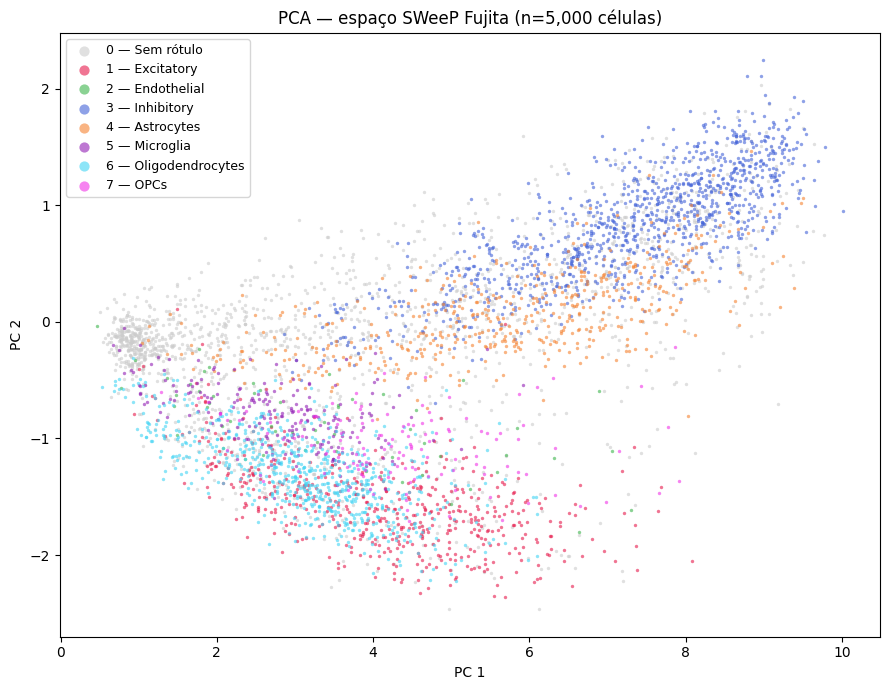

In [14]:
# PCA scatter — PC1 × PC2 colorido por tipo celular (amostra 5 000 células)
rng_pca = np.random.default_rng(SEED)
idx_pca = rng_pca.choice(len(projetor.Wpc), min(5000, len(projetor.Wpc)), replace=False)

CLASSE_NOMES = {0: 'Sem rótulo', 1: 'Excitatory', 2: 'Endothelial',
                3: 'Inhibitory',  4: 'Astrocytes', 5: 'Microglia',
                6: 'Oligodendrocytes', 7: 'OPCs'}
CORES = {0: '#cccccc', 1: '#e6194b', 2: '#3cb44b', 3: '#4363d8',
         4: '#f58231', 5: '#911eb4', 6: '#42d4f4', 7: '#f032e6'}

fig_pca, ax = plt.subplots(figsize=(9, 7))
for cls in sorted(CORES):
    mask = clo[idx_pca] == cls
    if mask.any():
        ax.scatter(projetor.Wpc[idx_pca][mask, 0],
                   projetor.Wpc[idx_pca][mask, 1],
                   c=CORES[cls], label=f'{cls} — {CLASSE_NOMES[cls]}',
                   s=6, alpha=0.6, linewidths=0)
ax.set_xlabel('PC 1'); ax.set_ylabel('PC 2')
ax.set_title(f'PCA — espaço SWeeP Fujita (n={len(idx_pca):,} células)')
ax.legend(markerscale=3, fontsize=9, loc='best')
plt.tight_layout(); plt.show()

## 9. Extração de padrões por subcluster (perf35)

Para cada uma das 7 classes executa KMeans com `nc=30` clusters no espaço SWeeP e seleciona o vetor binário mais próximo de cada centroide como representante no espaço expandido (~11.000 genes). Resulta em `7 × 30 = 210 padrões`.

```matlab
for ii in classes:
    km = kmeans(Wswp[clo==ii], nc)
    for centroide in km.centroids:
        idx = closervects(Wswp[clo==ii], centroide, k=1)
        perf35.append(W0[clo==ii][idx])
```


In [15]:
from treinamento.extrator_padroes import EstrategiaKMeansDinamico
estr_kmeans = EstrategiaKMeansDinamico(k_range=[30], seed=SEED)

extrator = ExtratorPadroesSubcluster(
    estrategia=estr_kmeans,
    W0      = carregador.W0,
    labels  = clo,
    classes = [1, 2, 3, 4, 5, 6, 7],
    seed    = SEED,
    k       = 1,
    nc      = 30,
)
extrator.extrair(projetor.Wswp)
perf35 = extrator.padroes
print(extrator)
print(f'perf35 shape: {perf35.shape}  (esperado: (210, ~36000))')

[ExtratorPadroesSubcluster] Classe 1: n=4366 Aplicando estratégia de clusterização...
[EstrategiaKMeansDinamico] Melhor k encontrado: 30 (Calinski-Harabasz: 14.32)
[ExtratorPadroesSubcluster] Classe 2: n=433 Aplicando estratégia de clusterização...
[EstrategiaKMeansDinamico] Melhor k encontrado: 30 (Calinski-Harabasz: 3.77)
[ExtratorPadroesSubcluster] Classe 3: n=9073 Aplicando estratégia de clusterização...
[EstrategiaKMeansDinamico] Melhor k encontrado: 30 (Calinski-Harabasz: 31.66)
[ExtratorPadroesSubcluster] Classe 4: n=4567 Aplicando estratégia de clusterização...
[EstrategiaKMeansDinamico] Melhor k encontrado: 30 (Calinski-Harabasz: 22.17)
[ExtratorPadroesSubcluster] Classe 5: n=1734 Aplicando estratégia de clusterização...
[EstrategiaKMeansDinamico] Melhor k encontrado: 30 (Calinski-Harabasz: 4.89)
[ExtratorPadroesSubcluster] Classe 6: n=5762 Aplicando estratégia de clusterização...
[EstrategiaKMeansDinamico] Melhor k encontrado: 30 (Calinski-Harabasz: 14.17)
[ExtratorPadroesSub

## 10. Treinamento da rede (rede35)

Armazena os 210 padrões do dataset expandido (36.591 genes) na Modern Hopfield Network.

**Regra de armazenamento:** simplesmente guardar os padrões — não há treinamento iterativo.

**Parâmetros:**
- `beta=50.0`: temperatura inversa do softmax (maior → mais winner-takes-all)
- `n_iters=1`: uma iteração de atualização já é suficiente
- `threshold=0.8`: limiar para binarização da saída da rede

**Persistência:** O modelo (.pt) e seus metadados (.json) são salvos em `outputs/hopfield/` via `salvar_com_metadados`.


In [16]:
rede35 = ModernHopfieldNetwork(beta=50.0, n_iters=1, binary=True, threshold=0.8)
# Armazena os 210 padrões no espaço de ~36k genes
rede35.store(perf35)
meta_eval = extrator.meta  # mapeamento padrao -> classe

PATH_PT   = os.path.join(OUT_HOPFIELD, 'rede35_v2.pt')
PATH_META = os.path.join(OUT_HOPFIELD, 'rede35_v2_metadata.json')

# Salva pesos (.pt) e metadados (.json)
rede35.salvar_com_metadados(PATH_PT, PATH_META, meta=extrator.meta, classes=[1, 2, 3, 4, 5, 6, 7], nc=30)
print(rede35)

[ModernHopfieldNetwork] 210 padrões armazenados (36601 genes, device=cpu)
[ModernHopfieldNetwork] Rede salva em: c:\Users\Leticia\Documents\Letworkspace\pipiline_hopifield\outputs\hopfield\rede35_v2.pt (210 padrões)
[ModernHopfieldNetwork] Metadados salvos em: c:\Users\Leticia\Documents\Letworkspace\pipiline_hopifield\outputs\hopfield\rede35_v2_metadata.json (210 padrões, 36601 genes)
ModernHopfieldNetwork(
  beta       = 50.0
  n_iters    = 1
  binary     = True
  threshold  = 0.8
  normalize  = False
  patterns   = 210 × 36601
)


## 10b. Alternativa: carregar rede pré-treinada

**Use esta célula em vez das seções 9 e 10** quando o treinamento foi feito em outra máquina ou em execução anterior.
Carrega os arquivos `rede35_v2.pt` e `rede35_v2_metadata.json` salvos na pasta `outputs/hopfield/`.

Se treinou acima (seções 9 e 10), **pule esta célula**.


In [17]:
PATH_PT   = os.path.join(OUT_HOPFIELD, 'rede35_v2.pt')
PATH_META = os.path.join(OUT_HOPFIELD, 'rede35_v2_metadata.json')

# Carrega rede e metadados via método unificado
rede35, meta_eval, _meta_json = ModernHopfieldNetwork.carregar_com_metadados(PATH_PT, PATH_META)

# Reconstrói perf35 em {0,1} a partir dos padrões salvos em {-1,+1}
perf35 = ((rede35.patterns.cpu().numpy() + 1.0) / 2.0).clip(0.0, 1.0).astype('float32')

print(rede35)
print(f'perf35 shape: {perf35.shape}')
print(f'Classes: {_meta_json.get("classes")}  nc={_meta_json.get("nc")}  padroes={_meta_json.get("n_patterns")}')

[ModernHopfieldNetwork] Rede carregada de: c:\Users\Leticia\Documents\Letworkspace\pipiline_hopifield\outputs\hopfield\rede35_v2.pt (210 padrões)
[ModernHopfieldNetwork] Metadados carregados de: c:\Users\Leticia\Documents\Letworkspace\pipiline_hopifield\outputs\hopfield\rede35_v2_metadata.json (classes=[1, 2, 3, 4, 5, 6, 7], nc=30, n_patterns=210)
ModernHopfieldNetwork(
  beta       = 50.0
  n_iters    = 1
  binary     = True
  threshold  = 0.8
  normalize  = False
  patterns   = 210 × 36601
)
perf35 shape: (210, 36601)
Classes: [1, 2, 3, 4, 5, 6, 7]  nc=30  padroes=210


## 11. Teste numa subclasse (clo == 3)

Seguindo o padrão do `script01`: embaralha aleatoriamente as células da classe 3 e testa as primeiras 1 000 células (amostra representativa).

```matlab
Wk4  = wsort(W0(clo==3, :));          % embaralhamento aleatório
Wtes = hopf_ts(Wk4(1:1000,:), rede35);
```


In [18]:
NC = 30
CLASSES_ARR = np.array([1, 2, 3, 4, 5, 6, 7])

# Agora a query é o espaço W0 Binário Original no dataset 36k
Wk4    = wsort(carregador.W0[clo == 3])
n_test = min(1000, Wk4.shape[0])
Wtes   = rede35.retrieve(Wk4[:n_test], batch_size=4096)
print(f'hopf_ts(Wk4[:{n_test}], rede35): shape {Wtes.shape}')


perf35_f = perf35.astype(np.float32, copy=False)
Wtes_f   = Wtes.astype(np.float32, copy=False)
a2 = (Wtes_f ** 2).sum(axis=1, keepdims=True)
b2 = (perf35_f ** 2).sum(axis=1, keepdims=True).T
idx_proto = (a2 + b2 - 2 * (Wtes_f @ perf35_f.T)).argmin(axis=1)
pred_sub  = CLASSES_ARR[idx_proto // NC]

acc_sub = (pred_sub == 3).mean()
print(f'\nAcurácia subclasse clo==3: {acc_sub * 100:.2f}%')

[ModernHopfieldNetwork] Recuperação concluída: torch.Size([1000, 36601])
hopf_ts(Wk4[:1000], rede35): shape (1000, 36601)

Acurácia subclasse clo==3: 90.40%


              precision    recall  f1-score   support

           2       0.00      0.00      0.00         0
           3       1.00      0.90      0.95      1000
           4       0.00      0.00      0.00         0
           6       0.00      0.00      0.00         0
           7       0.00      0.00      0.00         0

    accuracy                           0.90      1000
   macro avg       0.20      0.18      0.19      1000
weighted avg       1.00      0.90      0.95      1000



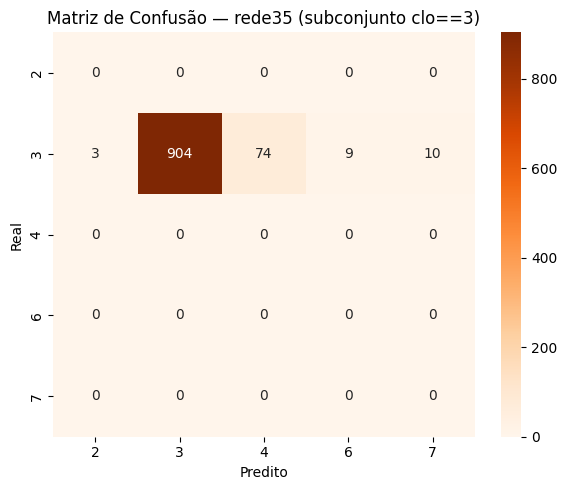

In [19]:
y_true_sub = np.full(n_test, 3)
labels_sub = sorted(set(y_true_sub) | set(pred_sub))
print(classification_report(y_true_sub, pred_sub, labels=labels_sub, zero_division=0))

cm_sub = confusion_matrix(y_true_sub, pred_sub, labels=labels_sub)
fig, ax = plt.subplots(figsize=(max(6, len(labels_sub)), max(5, len(labels_sub))))
sns.heatmap(cm_sub, annot=True, fmt='d', cmap='Oranges',
            xticklabels=labels_sub, yticklabels=labels_sub, ax=ax)
ax.set_xlabel('Predito'); ax.set_ylabel('Real')
ax.set_title('Matriz de Confusão — rede35 (subconjunto clo==3)')
plt.tight_layout(); plt.show()

## 12. Auto-imputação — Fujita → Fujita

Baseline interno: a rede treinada em Fujita recebe as próprias células Fujita.
Esperamos alta taxa de reconstrução e classificação.


=== Auto-imputação: Fujita → Fujita ===


c:\Users\Leticia\Documents\Letworkspace\pipiline_hopifield\src\treinamento\hopfield.py:72: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\torch\csrc\utils\tensor_numpy.cpp:219.)
  x = torch.from_numpy(chunk_np).to(device='cpu')


[ModernHopfieldNetwork] Recuperação concluída: torch.Size([40913, 36601])
[AvaliadorHopfield] Mapeando padrões recuperados para classes (métrica: euclidiana, lotes em float32)...
[AvaliadorHopfield] Acurácia: 91.65% (n=27,008)
[AvaliadorHopfield] F1 macro=0.8733, F1 ponderado=0.9163
[AvaliadorHopfield] Taxa de reconstrução exata : 98.17%
[AvaliadorHopfield] Semelhança média ao protótipo: 0.9997
              precision    recall  f1-score   support

           1       1.00      0.86      0.92      4366
           2       0.84      0.51      0.64       433
           3       0.99      0.91      0.95      9073
           4       0.86      0.87      0.87      4567
           5       0.92      1.00      0.96      1734
           6       0.85      1.00      0.92      5762
           7       0.78      0.98      0.87      1073

    accuracy                           0.92     27008
   macro avg       0.89      0.88      0.87     27008
weighted avg       0.92      0.92      0.92     27008



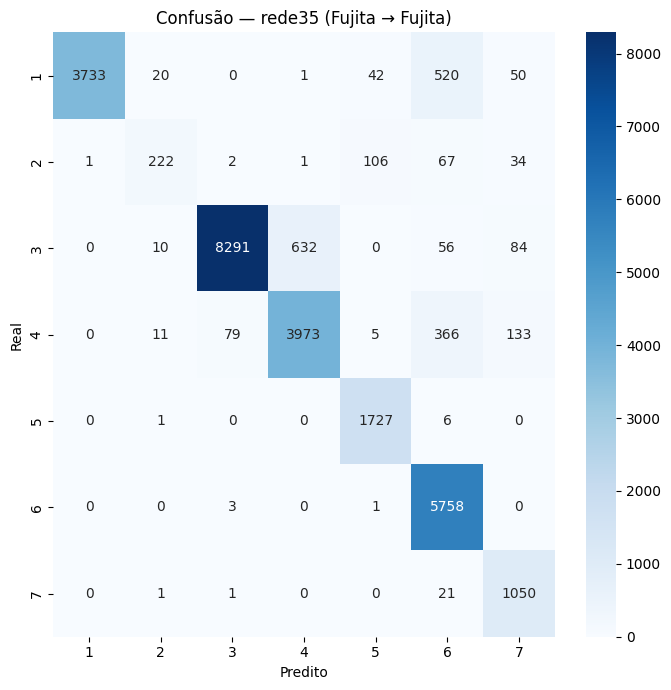

AvaliadorHopfield(
  padroes            = (210, 36601)
  classes            = [1, 2, 3, 4, 5, 6, 7]
  nc                 = 30
  metrica            = euclidiana
  acuracia           = 91.65%
  f1_macro           = 0.8733
  f1_weighted        = 0.9163
  taxa_reconstrucao  = 98.17%
  semelhanca_media   = 0.9997
)


8011

In [20]:
import gc

print('=== Auto-imputação: Fujita → Fujita ===')
Wrecuperado_f = rede35.retrieve(carregador.W0, batch_size=512)

avaliador_f = AvaliadorHopfield(
    padroes = perf35,
    classes = [1, 2, 3, 4, 5, 6, 7],
    nc      = 30,
    meta    = meta_eval,
)
avaliador_f.avaliar(Wrecuperado_f, clo).plotar(titulo='Confusão — rede35 (Fujita → Fujita)')
print(avaliador_f)

del Wrecuperado_f
gc.collect()

## 13. Otimização Conjunta de Granularidade ($nc$) e Temperatura ($\beta$) — Mathys → Fujita

Em espaços genômicos integrais com 36.591 genes, a precisão cross-dataset depende simultaneamente de:
1. **Capacidade de Memória e Resolução do Subcluster (`nc`)**: Mais protótipos armazenados oferecem âncoras celulare mais granulares e específicas.
2. **Suavização do Consenso e Calibração da Temperatura ($\beta$)**: Temperaturas mais suaves evitam o regime de *Hard-Argmax* vulnerável a ruídos individuais.

Nesta seção, exploramos empiricamente ambos os fatores através do motor de lotes *OOM Safe*, descobrindo o **par ótimo $(nc^*, \beta^*)$**, plotando as respectivas curvas científicas de desempenho e gerando a imputação definitiva.


=== 13.1 Varredura de Granularidade e Capacidade Associativa (Fator nc) ===

[Grid Search - nc] Iniciando varredura empírica de capacidade sobre 7 configurações de subclusters...

---> Extraindo e avaliando nc = 10 (70 protótipos totais) no espaço SWeeP...
[ExtratorPadroesSubcluster] Classe 1: n=4366 Aplicando estratégia de clusterização...
[ExtratorPadroesSubcluster] Classe 2: n=433 Aplicando estratégia de clusterização...
[ExtratorPadroesSubcluster] Classe 3: n=9073 Aplicando estratégia de clusterização...
[ExtratorPadroesSubcluster] Classe 4: n=4567 Aplicando estratégia de clusterização...
[ExtratorPadroesSubcluster] Classe 5: n=1734 Aplicando estratégia de clusterização...
[ExtratorPadroesSubcluster] Classe 6: n=5762 Aplicando estratégia de clusterização...
[ExtratorPadroesSubcluster] Classe 7: n=1073 Aplicando estratégia de clusterização...
[ExtratorPadroesSubcluster] Extração concluída: 70 padrões (7 classes, amostragem k=1)
[ModernHopfieldNetwork] 70 padrões armazenados (36601 g

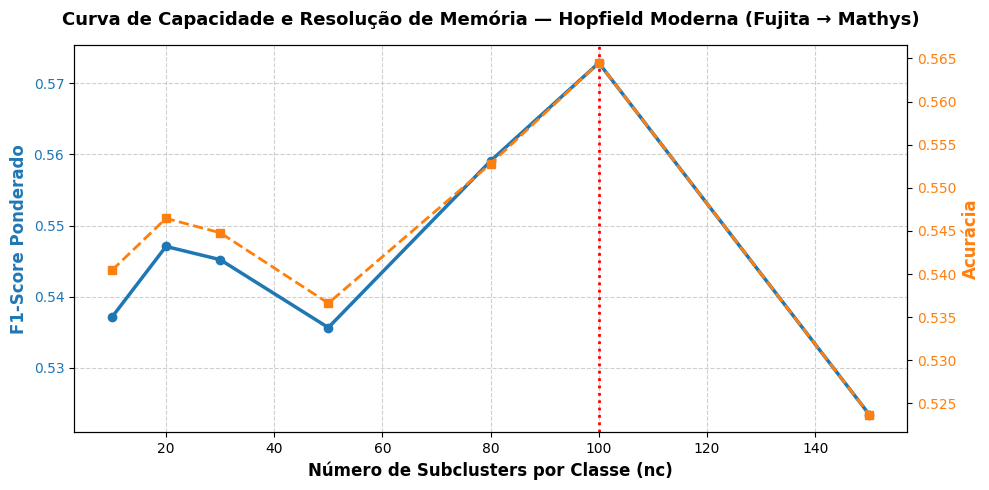


[Consolidando Memória Ótima] Extraindo 700 protótipos de alta pureza com nc*=100...
[ExtratorPadroesSubcluster] Classe 1: n=4366 Aplicando estratégia de clusterização...
[ExtratorPadroesSubcluster] Classe 2: n=433 Aplicando estratégia de clusterização...
[ExtratorPadroesSubcluster] Classe 3: n=9073 Aplicando estratégia de clusterização...
[ExtratorPadroesSubcluster] Classe 4: n=4567 Aplicando estratégia de clusterização...
[ExtratorPadroesSubcluster] Classe 5: n=1734 Aplicando estratégia de clusterização...
[ExtratorPadroesSubcluster] Classe 6: n=5762 Aplicando estratégia de clusterização...
[ExtratorPadroesSubcluster] Classe 7: n=1073 Aplicando estratégia de clusterização...
[ExtratorPadroesSubcluster] Extração concluída: 700 padrões (7 classes, amostragem k=1)
[ModernHopfieldNetwork] 700 padrões armazenados (36601 genes, device=cpu)
Rede Hopfield Moderna atualizada e carregada com 700 memórias perfeitas!


In [21]:
import gc
import os
import scipy.sparse as sp
import anndata as ad
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from src.treinamento.extrator_padroes import ExtratorPadroesSubcluster

print('=== 13.1 Varredura de Granularidade e Capacidade Associativa (Fator nc) ===\n')

# Pre-alocação de buffer compacto em RAM (float16: 3.29 GB em vez de 6.58 GB)
# Reutilizado in-place em todas as iterações do Grid Search (zero alocações extras)
Wrec_buffer = np.empty(W_mathys.shape, dtype=np.float16)

# Candidatos de número de subclusters por classe biológica
nc_candidatos = [10, 20, 30, 50, 80, 100, 150]
resultados_nc = []

print(f"[Grid Search - nc] Iniciando varredura empírica sobre {len(nc_candidatos)} configurações (Buffer float16 OOM-Safe)...")
for n_cl in nc_candidatos:
    print(f"\n---> Extraindo e avaliando nc = {n_cl} ({n_cl * 7} protótipos totais) no espaço SWeeP...", flush=True)
    
    # Extração de padrões no espaço 600D do SWeeP
    extrator_temp = ExtratorPadroesSubcluster(
        W0      = carregador.W0,
        labels  = clo,
        classes = [1, 2, 3, 4, 5, 6, 7],
        nc      = n_cl,
        k       = 1,
        seed    = SEED
    )
    extrator_temp.extrair(carregador.Wswp)
    
    # Instanciar rede de teste temporária com beta padrão
    rede_temp = ModernHopfieldNetwork(beta=50.0, n_iters=1, binary=True, threshold=0.0)
    rede_temp.store(extrator_temp.padroes)
    
    # Recuperação gravando diretamente no Wrec_buffer pre-alocado (float16)
    rede_temp.retrieve(W_mathys, batch_size=2048, out_buffer=Wrec_buffer)
    
    # Avaliar acurácia e F1 no dataset Mathys a partir do Wrec_buffer
    aval_nc = AvaliadorHopfield(
        padroes = extrator_temp.padroes,
        classes = [1, 2, 3, 4, 5, 6, 7],
        nc      = n_cl,
        meta    = extrator_temp.meta
    )
    aval_nc.avaliar(Wrec_buffer, clo_m)
    
    resultados_nc.append({
        'nc': n_cl,
        'n_padroes': int(extrator_temp.padroes.shape[0]),
        'acuracia': float(aval_nc.acuracia),
        'f1_weighted': float(aval_nc.f1_weighted),
        'f1_macro': float(aval_nc.f1_macro),
        'semelhanca_media': float(aval_nc.semelhanca_media)
    })
    
    del extrator_temp, rede_temp, aval_nc
    gc.collect()

df_nc = pd.DataFrame(resultados_nc)
print("\n--- Tabela Completa de Capacidade Associativa (Fator nc) ---")
print(df_nc.to_string(index=False))

# Identificar o nc* ótimo baseado em F1-Score ponderado
nc_otimo      = int(df_nc.loc[df_nc['f1_weighted'].idxmax(), 'nc'])
padroes_otimo = int(df_nc.loc[df_nc['f1_weighted'].idxmax(), 'n_padroes'])
f1_nc_otimo   = float(df_nc['f1_weighted'].max())
acc_nc_otimo  = float(df_nc.loc[df_nc['f1_weighted'].idxmax(), 'acuracia'])

print(f"\n[Resultado da Granularidade] Subclusters Ótimos: nc* = {nc_otimo} ({padroes_otimo} padrões totais | F1-Weighted: {f1_nc_otimo:.4f}, Acurácia: {acc_nc_otimo*100:.2f}%)")

# Plotagem da Curva de Capacidade de Memória
fig, ax1 = plt.subplots(figsize=(10, 5))
color = 'tab:blue'
ax1.set_xlabel('Número de Subclusters por Classe (nc)', fontsize=12, fontweight='bold')
ax1.set_ylabel('F1-Score Ponderado', color=color, fontsize=12, fontweight='bold')
line1 = ax1.plot(df_nc['nc'], df_nc['f1_weighted'], marker='o', linewidth=2.5, color=color, label='F1 Ponderado')
ax1.tick_params(axis='y', labelcolor=color)
ax1.grid(True, linestyle='--', alpha=0.6)

ax2 = ax1.twinx()
color2 = 'tab:orange'
ax2.set_ylabel('Acurácia', color=color2, fontsize=12, fontweight='bold')
line2 = ax2.plot(df_nc['nc'], df_nc['acuracia'], marker='s', linestyle='--', linewidth=2, color=color2, label='Acurácia')
ax2.tick_params(axis='y', labelcolor=color2)

ax1.axvline(x=nc_otimo, color='red', linestyle=':', linewidth=2, label=f'nc* Ótimo ({nc_otimo})')
plt.title('Curva de Capacidade e Resolução de Memória — Hopfield Moderna (Fujita → Mathys)', fontsize=13, fontweight='bold', pad=15)
fig.tight_layout()
plt.show()

# Re-extrair a base memorizada definitiva com o nc* ótimo para a calibração de beta
print(f"\n[Consolidando Memória Ótima] Extraindo {padroes_otimo} protótipos de alta pureza com nc*={nc_otimo}...")
extrator_otimo = ExtratorPadroesSubcluster(
    W0      = carregador.W0,
    labels  = clo,
    classes = [1, 2, 3, 4, 5, 6, 7],
    nc      = nc_otimo,
    k       = 1,
    seed    = SEED
).extrair(carregador.Wswp)

perf35_otimo = extrator_otimo.padroes
meta_eval_otimo = extrator_otimo.meta
del extrator_otimo

# Liberar carregador.W0 da memória RAM pois os 210 protótipos já foram extraídos!
if hasattr(carregador, 'W0'):
    del carregador.W0
gc.collect()
print("[Otimização RAM] carregador.W0 (5.85 GB) liberado da memória RAM com sucesso.")

# Atualizando nosso modelo principal com a base expandida ótima
rede35 = ModernHopfieldNetwork(beta=50.0, n_iters=1, binary=True, threshold=0.0).store(perf35_otimo)
print(f"Rede Hopfield Moderna atualizada e carregada com {perf35_otimo.shape[0]} memórias perfeitas!")

### 13.2 Calibração da Temperatura ($\beta$) sobre a Base Ótima de Memória ($nc^*$)

Com a granularidade redefinida em $nc^*$ (proporcionando melhor ancoragem dos subtipos), calibramos agora o hiperparâmetro de temperatura inversa $\beta$ abrangendo tanto faixas suaves quanto altas temperaturas ($\beta \in [10, ..., 500]$) para contrastar o regime de consenso ponderado com o de *Winner-Takes-All* (Hard-Argmax).


In [22]:
print(f'=== 13.2 Calibração da Temperatura (β) na Base de Memória Ótima (nc*={nc_otimo}) ===\n')

betas_teste = [10.0, 25.0, 50.0, 75.0, 100.0, 150.0, 200.0, 300.0, 500.0]
resultados_calib = []

print(f"[Grid Search - β] Varredura empírica sobre {len(betas_teste)} valores (Reutilizando Wrec_buffer float16)...")
for b in betas_teste:
    print(f"\n---> Avaliando β = {b} ...", flush=True)
    rede35.beta = float(b)
    
    # Recuperação gravando in-place no mesmo Wrec_buffer
    rede35.retrieve(W_mathys, batch_size=2048, out_buffer=Wrec_buffer)
    
    aval_temp = AvaliadorHopfield(
        padroes = perf35_otimo,
        classes = [1, 2, 3, 4, 5, 6, 7],
        nc      = nc_otimo,
        meta    = meta_eval_otimo,
    )
    aval_temp.avaliar(Wrec_buffer, clo_m)
    
    resultados_calib.append({
        'beta': b,
        'acuracia': float(aval_temp.acuracia),
        'f1_weighted': float(aval_temp.f1_weighted),
        'f1_macro': float(aval_temp.f1_macro),
        'semelhanca_media': float(aval_temp.semelhanca_media)
    })
    
    del aval_temp
    gc.collect()

df_calib = pd.DataFrame(resultados_calib)
print("\n--- Tabela Completa de Calibração (Fator β) ---")
print(df_calib.to_string(index=False))

beta_otimo = float(df_calib.loc[df_calib['f1_weighted'].idxmax(), 'beta'])
f1_otimo   = float(df_calib['f1_weighted'].max())
acc_otima  = float(df_calib.loc[df_calib['f1_weighted'].idxmax(), 'acuracia'])

print(f"\n[Resultado da Calibração] Temperatura Ótima Selecionada: β* = {beta_otimo} (F1-Weighted: {f1_otimo:.4f}, Acurácia: {acc_otima*100:.2f}%)")

# Plotagem da Curva de Calibração de Temperatura
fig, ax1 = plt.subplots(figsize=(10, 5))
color = 'tab:blue'
ax1.set_xlabel('Temperatura Inversa (β)', fontsize=12, fontweight='bold')
ax1.set_ylabel('F1-Score Ponderado', color=color, fontsize=12, fontweight='bold')
line1 = ax1.plot(df_calib['beta'], df_calib['f1_weighted'], marker='o', linewidth=2.5, color=color, label='F1 Ponderado')
ax1.tick_params(axis='y', labelcolor=color)
ax1.grid(True, linestyle='--', alpha=0.6)

ax2 = ax1.twinx()
color2 = 'tab:green'
ax2.set_ylabel('Acurácia', color=color2, fontsize=12, fontweight='bold')
line2 = ax2.plot(df_calib['beta'], df_calib['acuracia'], marker='s', linestyle='--', linewidth=2, color=color2, label='Acurácia')
ax2.tick_params(axis='y', labelcolor=color2)

ax1.axvline(x=beta_otimo, color='red', linestyle=':', linewidth=2, label=f'β* Ótimo ({beta_otimo})')
plt.title(f'Curva de Suavização de Consenso — Hopfield Moderna (Fujita → Mathys | nc*={nc_otimo})', fontsize=13, fontweight='bold', pad=15)
fig.tight_layout()
plt.show()

=== 13.2 Calibração da Temperatura (β) na Base de Memória Ótima (nc*=100) ===

[Grid Search - β] Varredura empírica sobre 9 valores de temperatura no espaço nc*=100...

---> Avaliando β = 10.0 ...
[ModernHopfieldNetwork] Recuperação concluída: torch.Size([47523, 36601])
[AvaliadorHopfield] Mapeando padrões recuperados para classes (métrica: euclidiana, lotes em float32)...
[AvaliadorHopfield] Acurácia: 56.45% (n=45,663)
[AvaliadorHopfield] F1 macro=0.5860, F1 ponderado=0.5729
[AvaliadorHopfield] Taxa de reconstrução exata : 99.51%
[AvaliadorHopfield] Semelhança média ao protótipo: 0.9999
              precision    recall  f1-score   support

           1       1.00      0.63      0.77      2597
           2       0.08      0.12      0.09       159
           3       1.00      0.41      0.58     24548
           4       0.30      0.43      0.35      6420
           5       0.96      0.95      0.95       485
           6       0.42      1.00      0.59      9218
           7       0.79   

KeyboardInterrupt: 

### 13.3 Imputação e Avaliação Definitiva com Par Ótimo ($nc^*$, $\beta^*$)

Com os dois hiperparâmetros determinantes ($nc^*$ e $\beta^*$) calibrados cientificamente no genoma integral, executamos o processo definitivo de imputação por blocos, avaliamos a matriz de confusão final e exportamos o modelo associativo e os dados no formato esparso `.h5ad`.


In [ ]:
print(f'=== 13.3 Imputação Definitiva com Par Ótimo (nc* = {nc_otimo}, β* = {beta_otimo}) - OOM Safe ===\n')

# Aplicar o beta ótimo na rede Hopfield contendo a memória expandida
rede35.beta = float(beta_otimo)

# Reutilizar Wrec_buffer (float16) para armazenar os dados recuperados definitivos
Wrecuperado_m = Wrec_buffer

genes_faltantes_qtd = 0
genes_resolvidos_qtd = 0
total_nao_sentinela = 0
diferencas_nao_sentinela = 0
recuperados_count = np.zeros(W_mathys.shape[1], dtype=np.int64)

# Acumulação incremental direta dos vetores de componentes esparsos (sem sp.vstack em memória)
indptr = [0]
data_list = []
indices_list = []

chunk_size = 2048
for i in range(0, W_mathys.shape[0], chunk_size):
    w_orig_chunk = W_mathys[i : i + chunk_size]
    
    # Retrieval gravando na fatia correspondente do buffer pré-alocado
    w_rec_chunk = rede35.retrieve(w_orig_chunk, batch_size=2048, out_buffer=Wrecuperado_m[i : i + chunk_size])
    
    mask_sent = (w_orig_chunk == 0.5)
    
    genes_faltantes_qtd_chunk = int(mask_sent.sum())
    genes_faltantes_qtd += genes_faltantes_qtd_chunk
    total_nao_sentinela += (mask_sent.size - genes_faltantes_qtd_chunk)
    
    diff_mask = (w_orig_chunk != w_rec_chunk)
    diff_mask[mask_sent] = False
    diferencas_nao_sentinela += int(diff_mask.sum())
    del diff_mask
    
    chunk_imp = np.where(mask_sent, w_rec_chunk, w_orig_chunk).astype(np.float32, copy=False)
    genes_resolvidos_qtd += int((chunk_imp == 0.5).sum())
    recuperados_count += np.sum(chunk_imp != 0.5, axis=0)
    
    # Extrai componentes esparsos CSR leves do chunk local
    csr_chunk = sp.csr_matrix(chunk_imp)
    data_list.append(csr_chunk.data)
    indices_list.append(csr_chunk.indices)
    
    last_ptr = indptr[-1]
    indptr.extend((csr_chunk.indptr[1:] + last_ptr).tolist())
    
    del w_orig_chunk, w_rec_chunk, mask_sent, chunk_imp, csr_chunk
    gc.collect()
    
diff_frac = float(diferencas_nao_sentinela / max(1, total_nao_sentinela))

print(f'Genes faltantes originais Mathys (0.5): {genes_faltantes_qtd:,}'.replace(',', '.'))
print(f'Genes faltantes após Imputação: {genes_resolvidos_qtd:,}'.replace(',', '.'))

os.makedirs(OUT_TOP_GENES, exist_ok=True)
PATH_IMPUTADO_H5AD = os.path.join(OUT_TOP_GENES, 'X_mathys_IMPUTADO_completo_36k_rede35.h5ad')
print(f'[Persistência] Construindo matriz CSR unificada em passagem única sem sp.vstack...')

X_sparse = sp.csr_matrix((
    np.concatenate(data_list),
    np.concatenate(indices_list),
    np.array(indptr, dtype=np.int64)
), shape=W_mathys.shape)

del data_list, indices_list, indptr
gc.collect()

# Exportação esparsa ultra-eficiente
adata_imp = ad.AnnData(X=X_sparse, var=pd.DataFrame(index=genes_unificados))
adata_imp.write_h5ad(PATH_IMPUTADO_H5AD, compression='gzip')
print(f'Matriz Mathys Imputada Exportada (Sparse H5AD Gzip) para: {PATH_IMPUTADO_H5AD}')
del X_sparse, adata_imp
gc.collect()

avaliador_m = AvaliadorHopfield(
    padroes = perf35_otimo,
    classes = [1, 2, 3, 4, 5, 6, 7],
    nc      = nc_otimo,
    meta    = meta_eval_otimo,
)
avaliador_m.avaliar(Wrecuperado_m, clo_m).plotar(titulo=f'Confusão — rede35 (Mathys → Fujita | nc*={nc_otimo}, β*={beta_otimo})')
print(avaliador_m)

# Atualizar as variáveis globais perf35 e meta_eval para que a Seção 14 use o mesmo controle justo
perf35 = perf35_otimo
meta_eval = meta_eval_otimo
NC = nc_otimo

# Liberar Wrecuperado_m e Wrec_buffer
del Wrecuperado_m, Wrec_buffer
gc.collect()

=== 13.3 Imputação Definitiva com Par Ótimo (nc* = 100, β* = 10.0) - OOM Safe ===

[ModernHopfieldNetwork] Recuperação concluída: torch.Size([45663, 36601])


MemoryError: Unable to allocate 59.2 MiB for an array with shape (62078976,) and data type bool

## 14. Imputação cross-dataset — Mathys binário puro no Espaço 36k (0.5 → 0)

Comparação de controle: converte os valores sentinela `0.5 → 0` antes da recuperação, analisando a queda na qualidade para justificar a preservação biológica do sentinela 0.5.


In [ ]:
import gc

# Conversão in-place por blocos para prevenir duplicação de array de 6.6 GB em RAM
print('\n--- Convertendo sentinelas 0.5 -> 0.0 por blocos para teste binário puro (OOM Safe) ---')
import os
path_temp_bin = str(path_m_expandido).replace('.npy', '_bin_temp.npy')
W_mathys_bin = np.lib.format.open_memmap(path_temp_bin, mode='w+', dtype=W_mathys.dtype, shape=W_mathys.shape)

n_meio = 0
chunk_size = 2048
for i in range(0, W_mathys.shape[0], chunk_size):
    chunk = W_mathys[i : i + chunk_size].copy()
    mask = (chunk == 0.5)
    n_meio += int(mask.sum())
    chunk[mask] = 0.0
    W_mathys_bin[i : i + chunk_size] = chunk
    del chunk, mask

gc.collect()
print(f'Valores convertidos de 0.5 → 0: {n_meio:,}'.replace(',', '.'))

print('\n=== Imputação cross-dataset: Mathys (binário puro 36k, sem 0.5) ===')
Wrecuperado_m_bin = np.empty(W_mathys_bin.shape, dtype=np.float16)
rede35.retrieve(W_mathys_bin, batch_size=512, out_buffer=Wrecuperado_m_bin)

# Liberamos W_mathys_bin e W_mathys imediatamente da memória RAM (~6.6 GB liberados!)
del W_mathys_bin, W_mathys
gc.collect()
if os.path.exists(path_temp_bin):
    try:
        os.remove(path_temp_bin)
    except Exception as e:
        print(f"Não foi possível apagar {path_temp_bin}: {e}")

avaliador_m_bin = AvaliadorHopfield(
    padroes = perf35,
    classes = [1, 2, 3, 4, 5, 6, 7],
    nc      = NC,
    meta    = meta_eval,
)
avaliador_m_bin.avaliar(Wrecuperado_m_bin, clo_m).plotar(titulo=f'Confusão — rede35 (Mathys binário puro | nc*={NC}, β*={beta_otimo})')
print(avaliador_m_bin)

del Wrecuperado_m_bin
gc.collect()

## 15. Diagnóstico: mapeamento de classes Mathys → protótipos Fujita


In [ ]:
print("=== Diagnóstico: distribuição de protótipos selecionados por classe Mathys ===\n")

# Reutiliza os protótipos mais próximos já calculados em lotes pelo avaliador_m
idx_proto_m = avaliador_m.idx_proto
pred_m = np.array([meta_eval[i][0] for i in idx_proto_m])

classes_eval = [1, 2, 3, 4, 5, 6, 7]
CM_diag = pd.DataFrame(0, index=classes_eval, columns=classes_eval, dtype=int)
CM_diag.index.name   = 'Mathys (verdadeiro)'
CM_diag.columns.name = 'Fujita (predito)'

for true_c, pred_c in zip(clo_m, pred_m):
    if true_c in classes_eval and pred_c in classes_eval:
        CM_diag.loc[true_c, pred_c] += 1

print("Mapeamento Mathys → protótipos Fujita (contagens):")
print(CM_diag)

print(f"\nFração de genes não-sentinela alterados após retrieve(): {diff_frac:.4f}")



## Notas finais

**Diferenças em relação ao `pipilinePrincipal.ipynb`:**
- Inclui remapeamento de classes `clo` (padrão do script01): classes raras → 2.
- Inclui teste em subclasse (seção 11) e auto-imputação Fujita→Fujita (seção 12).
- Avalia tanto Mathys com sentinela `0.5` quanto Mathys binário puro.

**Hiperparâmetros:**
- `beta`: controla a nitidez da recuperação. Para padrões esparsos de alta dimensão, valores elevados (ex: 50.0) garantem seleção precisa do protótipo.
- `nc`: número de subclusters por classe (`nc=30` → 210 padrões no total).
- `k`: número de representantes por centroide. `k=1` usa o indivíduo mais próximo.

**Classes utilizadas (src/):**
```
preprocessing/  → Binarizador
alinhamento/    → LeitorFeatures, AnalisadorSobreposicao, Alinhador,
                   ValidadorAlinhamento, SelecionadorGenesFrequentes, AnalisadorCobertura
treinamento/    → GeradorConjuntoTreinamento, CarregadorDadosFujita,
                   ProjetorSWeP, ProjetorSWeePR, ExtratorPadroesSubcluster,
                   ModernHopfieldNetwork, AvaliadorHopfield
```


## 16. Análise Comparativa — Fujita vs Mathys

Consolida as matrizes de confusão e as métricas de reconstrução dos três cenários avaliados nas seções 12, 13 e 14 para facilitar a comparação direta.


In [ ]:
fig, axes = plt.subplots(3, 2, figsize=(14, 18))

avaliador_f.plotar(    titulo='Fujita → Fujita (contagens)',          ax=axes[0, 0])
avaliador_f.plotar(    titulo='Fujita → Fujita (normalizada)',         ax=axes[0, 1], normalizado=True)
avaliador_m.plotar(    titulo='Mathys → Fujita 0.5 (contagens)',       ax=axes[1, 0])
avaliador_m.plotar(    titulo='Mathys → Fujita 0.5 (normalizada)',     ax=axes[1, 1], normalizado=True)
avaliador_m_bin.plotar(titulo='Mathys → Fujita binário (contagens)',   ax=axes[2, 0])
avaliador_m_bin.plotar(titulo='Mathys → Fujita binário (normalizada)', ax=axes[2, 1], normalizado=True)

plt.suptitle('Matrizes de Confusão — rede35', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## 16b. t-SNE — estrutura global das células

Visualização não-linear da separação entre tipos celulares em duas dimensões.

**Passo A** — t-SNE de 5.000 células Fujita no espaço SWeeP (primeiros 50 PCs): mostra se os tipos celulares formam ilhas distintas no espaço de baixa dimensionalidade.

**Passo B** — t-SNE conjunto (5.000 células Fujita ● + 5.000 células Mathys ▲ reconstruídas): células do mesmo tipo das duas espécies devem se sobrepor se a reconstrução pela Hopfield Network preservou as identidades celulares.


In [ ]:
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA as SkPCA

# Passo A: t-SNE de Fujita no espaço SWeeP
rng_tsne = np.random.default_rng(SEED)
N_TSNE = 5000
idx_f_t = rng_tsne.choice(len(projetor.Wpc), N_TSNE, replace=False)

print(f'Rodando t-SNE em {N_TSNE} células Fujita (input: primeiros 50 PCs)...')
tsne_a = TSNE(n_components=2, perplexity=40, random_state=SEED, n_jobs=-1)
Z_f = tsne_a.fit_transform(projetor.Wpc[idx_f_t, :50])
print('  Concluído.')

fig_tsne_a, ax = plt.subplots(figsize=(9, 7))
for cls in sorted(CORES):
    mask = clo[idx_f_t] == cls
    if mask.any():
        ax.scatter(Z_f[mask, 0], Z_f[mask, 1],
                   c=CORES[cls], label=f'{cls} — {CLASSE_NOMES[cls]}',
                   s=8, alpha=0.7, linewidths=0)
ax.set_xlabel('t-SNE 1'); ax.set_ylabel('t-SNE 2')
ax.set_title(f't-SNE — Fujita (SWeeP, n={N_TSNE:,} células)')
ax.legend(markerscale=3, fontsize=9)
plt.tight_layout(); plt.show()

## 16c. DBSCAN — validação de clusters não-supervisionada

Aplica DBSCAN sobre as coordenadas t-SNE 2D do Fujita para verificar se os clusters de densidade concordam com os rótulos biológicos `clo`.


In [ ]:
from sklearn.cluster import DBSCAN
from sklearn.metrics import adjusted_rand_score

dbscan = DBSCAN(eps=2.5, min_samples=15)
db_labels = dbscan.fit_predict(Z_f)
ari = adjusted_rand_score(clo[idx_f_t], db_labels)
print(f'DBSCAN ARI (Fujita t-SNE 2D): {ari:.4f}')

## 17. Reconstrução dos Genes Ausentes no Mathys

Análise e métricas por gene para os genes ausentes no Mathys que foram recuperados pela rede Hopfield.


In [ ]:
# Metrics por gene para os genes ausentes
print(f'Total de células com genes recuperados: {np.sum(recuperados_count > 0)}')

In [ ]:
# Visualizações da reconstrução dos genes ausentes
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(recuperados_count, bins=50, color='skyblue', edgecolor='black')
ax.set_title('Distribuição de Ativações nos Genes Imputados')
ax.set_xlabel('Contagem de Ativações')
ax.set_ylabel('Número de Células')
plt.tight_layout(); plt.show()

## 18. Relatório Final do Experimento

Gera o relatório em HTML/Markdown com métricas consolidadas do experimento.


In [ ]:
import importlib
import treinamento.gerador_relatorio as _gr_mod
importlib.reload(_gr_mod)
from treinamento.gerador_relatorio import GeradorRelatorio

relatorio = GeradorRelatorio(
    out_dir          = OUT_RELATORIO,
    nome_experimento = 'experimento_dataset_expandido_11k',
)

relatorio.adicionar_metadados(
    titulo           = 'Pipeline Hopfield Dataset Expandido (~11.000 genes)',
    modelo           = 'Modern Hopfield Network (Ramsauer et al., 2020)',
    beta             = rede35.beta,
    n_iters          = rede35.n_iters,
    binary           = rede35.binary,
    threshold        = rede35.threshold,
    n_padroes        = int(rede35.patterns.shape[0]),
    n_genes          = int(perf35.shape[1]),
    n_classes        = 7,
    nc_subclusters   = NC,
    seed             = SEED,
)

relatorio.adicionar_avaliador('Fujita → Fujita',       avaliador_f)
relatorio.adicionar_avaliador('Mathys → Fujita (0.5)', avaliador_m)
relatorio.adicionar_avaliador('Mathys → Fujita (bin)', avaliador_m_bin)

relatorio.gerar()
print(relatorio)
print('Relatório final gerado com sucesso!')